In [51]:
# setting up
import os
import subprocess
from more_itertools import strip
import numpy as np
import seaborn as sea

# shortcuts
home = '~/research/'
phylobc_script = home + 'nielsen_lab/phylogenetic-base-calling/call_bases_from_pileup.py'
verr_sims_folder_path = home + 'rotations/r3_nielsen/2023spring/sim_results_verr/'
cerr_sims_folder_path = home + 'rotations/r3_nielsen/2023spring/sim_results_verr_compare/'

# Was original reference db abundant in N's?

<AxesSubplot:ylabel='Count'>

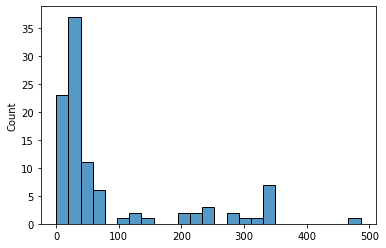

In [64]:
# tally up N's per sample using initial fasta
og_fasta_path = "/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/step1_msa/SARS-CoV-2_100genomes.fasta"
with open(og_fasta_path) as file:
    unaligned_seqs = [line.rstrip() for line in file]
names = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 == 0] # even indexes are names
seqs = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 != 0] # uneven indexes are sequences

n_counts = [sum([1 for b in list(seq) if b.lower()=='n']) for seq in seqs]
sea.histplot(n_counts, cumulative=False)

In [62]:
max(n_counts)

486

# MSA using only sequences without excess N's

<AxesSubplot:ylabel='Count'>

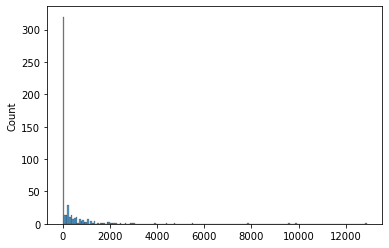

In [63]:
# tally up N's per sample using initial fasta
og_fasta_path = "/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/step1_msa/SARS-CoV-2_500genomes.fasta"
with open(og_fasta_path) as file:
    unaligned_seqs = [line.rstrip() for line in file]
names = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 == 0] # even indexes are names
seqs = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 != 0] # uneven indexes are sequences

n_counts = [sum([1 for b in list(seq) if b.lower()=='n']) for seq in seqs]
sea.histplot(n_counts, cumulative=False)

In [56]:
# remove too many N's and create new fasta
indexes_to_keep = [i for i,n in enumerate(n_counts) if n<10]
with open('/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/step1_msa/SARS-CoV-2_282genomes.fasta', 'a') as f:
    for i in indexes_to_keep:
        f.write( names[i] + '\n' + seqs[i] + '\n')
f.close()

In [59]:
len(indexes_to_keep)

282

# Finding dups in the multiple sequence alignment (MSA)

In [7]:
# old 100-seq MSA is at:
# /Users/marniella/research/rotations/r3_nielsen/2022fall/alignment101_mafft2/alignment101.fasta

## > 500-seq MSA -> excess N's out -> 284-seq MSA

In [4]:
msa_path = "/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/step1_msa/msa284.fasta"
with open(msa_path) as file:
    msa_seqs = [line.rstrip() for line in file]
names = [msa_seqs[i] for i in range(len(msa_seqs)) if i%2 == 0] # even indexes are names
seqs = [msa_seqs[i] for i in range(len(msa_seqs)) if i%2 != 0] # uneven indexes are sequences

### Hashing the cropped sequences: too many unique

In [5]:
# create a dictionary of the sequences but cropping out the heads/tails
msa_dict_crop = {seq[1000:-1000]:names for seq in seqs}
print(len(msa_dict_crop))

282


### Hashing sequences w/o N's or gaps: too few unique

In [6]:
## try different approach
# get all the sites that have an N or gap
keep_sites = [True]*len(seqs[0])
for s in seqs:
    for i in range(len(keep_sites)):
        if s[i].lower() == 'n':
            keep_sites[i] = False

# now take them out of all the sequences
no_n_seqs = [''.join([og_seq[keep] for keep in range(len(keep_sites)) if keep==True]) for og_seq in seqs]

# now create a dictionary of the N's-removed sequences
msa_dict_no_n = {no_n_seqs[i]:names[i] for i in range(len(names))}
print(len(msa_dict_no_n))

3


### Pairwise comparison

In [ ]:
def are_bases_distinct(a,b):
    # N's don't make bases distinct
    if (a.lower() == 'n') or (b.lower() == 'n'):
        return False
    else:
        return not (a==b)

def might_be_same(s1, s2):
    # return the sequence with most bases
    return 0

# def compare_seqs(seq1, seq2):
#     # for

In [9]:
import pandas as pd

In [10]:
# how are the pruned and not pruned priors different?
pruned_prior_dir = '/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/ou_pruned/'
not_pruned_prior_dir = '/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/ou_not_pruned/'

pruned_prior_df = pd.read_csv(pruned_prior_dir + 'OU_PP_indexed.txt', sep = '\t', index_col='position')
not_pruned_prior_df = pd.read_csv(not_pruned_prior_dir + 'OU_PP_indexed.txt', sep = '\t', index_col='position')

In [14]:
pruned_max_base = [base[3:] for base in pruned_prior_df.idxmax(axis=1)]
not_pruned_max_base = [base[3:] for base in pruned_prior_df.idxmax(axis=1)]

diffs = [(pos,pb,npb) for pos,(pb,npb) in enumerate(zip(pruned_max_base,not_pruned_max_base)) if pb!=npb]
print(diffs)

In [19]:
pruned_vs_not_diff = pruned_prior_df - pruned_prior_df
# check out the differences

In [18]:
for pos,(pb,npb) in enumerate(zip(pruned_max_base,not_pruned_max_base)):
    if pb==npb:
        print(pos, (pb,npb))

0 ('A', 'A')
1 ('T', 'T')
2 ('T', 'T')
3 ('A', 'A')
4 ('A', 'A')
5 ('A', 'A')
6 ('G', 'G')
7 ('G', 'G')
8 ('T', 'T')
9 ('T', 'T')
10 ('T', 'T')
11 ('A', 'A')
12 ('T', 'T')
13 ('T', 'T')
14 ('A', 'A')
15 ('C', 'C')
16 ('C', 'C')
17 ('C', 'C')
18 ('T', 'T')
19 ('T', 'T')
20 ('C', 'C')
21 ('C', 'C')
22 ('C', 'C')
23 ('A', 'A')
24 ('G', 'G')
25 ('G', 'G')
26 ('T', 'T')
27 ('A', 'A')
28 ('A', 'A')
29 ('C', 'C')
30 ('A', 'A')
31 ('A', 'A')
32 ('A', 'A')
33 ('C', 'C')
34 ('C', 'C')
35 ('A', 'A')
36 ('A', 'A')
37 ('C', 'C')
38 ('C', 'C')
39 ('A', 'A')
40 ('A', 'A')
41 ('C', 'C')
42 ('T', 'T')
43 ('T', 'T')
44 ('T', 'T')
45 ('C', 'C')
46 ('G', 'G')
47 ('A', 'A')
48 ('T', 'T')
49 ('C', 'C')
50 ('T', 'T')
51 ('C', 'C')
52 ('T', 'T')
53 ('T', 'T')
54 ('G', 'G')
55 ('T', 'T')
56 ('A', 'A')
57 ('G', 'G')
58 ('A', 'A')
59 ('T', 'T')
60 ('C', 'C')
61 ('T', 'T')
62 ('G', 'G')
63 ('T', 'T')
64 ('T', 'T')
65 ('C', 'C')
66 ('T', 'T')
67 ('C', 'C')
68 ('T', 'T')
69 ('A', 'A')
70 ('A', 'A')
71 ('A', 'A')
72